# Cruz Azul — Análisis Inteligente Liga MX
## 10 Preguntas de Negocio: Cruz Azul y la Liga MX

**Fuentes:** `master_jugadores.parquet` (1 150 jugadores × 38 cols) + `master_partidos.parquet` (4 080 partidos × 19 cols)

| # | Pregunta | Tipo |
|---|----------|------|
| P1 | ¿Cuánto vale un jugador de Cruz Azul vs perfiles similares? | Descriptivo |
| P2 | Evolución del valor de plantilla: Cruz Azul vs América vs Rayados | Descriptivo |
| P3 | ¿Cruz Azul rinde mejor en casa que fuera? | Descriptivo |
| P4 | Extranjeros vs nacionales dentro del club | Descriptivo |
| P5 | Equipos con mayor brecha FIFA vs Transfermarkt (talento oculto) | Descriptivo |
| P6 | Probabilidad de transferencia de jugadores | **Predictivo** |
| P7 | Valor de mercado esperado dado rendimiento FIFA | **Predictivo** |
| P8 | Predicción de resultado de partidos Cruz Azul | **Predictivo** |
| P9 | Mejor mediocampista disponible ≤ 3 M USD para Cruz Azul | Prescriptivo |
| P10 | Debilidades tácticas de Cruz Azul y perfil a fichar | Prescriptivo |

In [16]:
# ── Dependencias ──────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ──────────────────────────────────────────────────────────────────────
BASE = 'C:/Users/Unredeemer/Desktop/Proyecto_Final_Calidad'
df       = pd.read_parquet(os.path.join(BASE, 'datos_master', 'master_jugadores.parquet'))
partidos = pd.read_parquet(os.path.join(BASE, 'datos_master', 'master_partidos.parquet'))

# ── Helpers de filtrado por equipo ─────────────────────────────────────────────
def es_ca(s):  return s.str.contains('Cruz Azul',         case=False, na=False)
def es_am(s):  return s.str.contains('Am.rica',            case=False, na=False, regex=True)
def es_ray(s): return s.str.contains('Monterrey|Rayados', case=False, na=False, regex=True)

CA = df[es_ca(df['equipo_norm'])].copy()

print('Jugadores cargados :', df.shape)
print('Partidos  cargados :', partidos.shape)
print('Cruz Azul — registros en dataset:', len(CA))
n_eq = df['equipo_norm'].nunique()
print('Equipos únicos:', n_eq)
temps = sorted(df['season_year'].dropna().unique().astype(int).tolist())
print('Temporadas disponibles:', temps)
print('Columnas jugadores:', list(df.columns))

Jugadores cargados : (1150, 38)
Partidos  cargados : (4080, 19)
Cruz Azul — registros en dataset: 52
Equipos únicos: 28
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Columnas jugadores: ['player_id', 'nombre_canonico', 'nombre_key', 'nombre_transfermarkt', 'nombre_fifa', 'nombre_football_csv', 'sim_tm_fifa', 'sim_tm_csv', 'posicion', 'nacionalidad', 'segunda_nacionalidad', 'es_extranjero', 'doble_nacionalidad', 'edad', 'temporada', 'season_year', 'equipo', 'equipo_norm', 'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical', 'valor_mercado_eur', 'transfer_paid_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'inconsistencias']


---
## P1 — ¿Cuánto vale un jugador de Cruz Azul respecto a perfiles similares en la liga?
> **Método:** Percentiles de valor de mercado por posición + percentil de FIFA Overall de cada jugador de Cruz Azul dentro de su posición.  
> **Visualización:** Boxplots por posición con jugadores Cruz Azul como puntos rojos + barras de percentil.

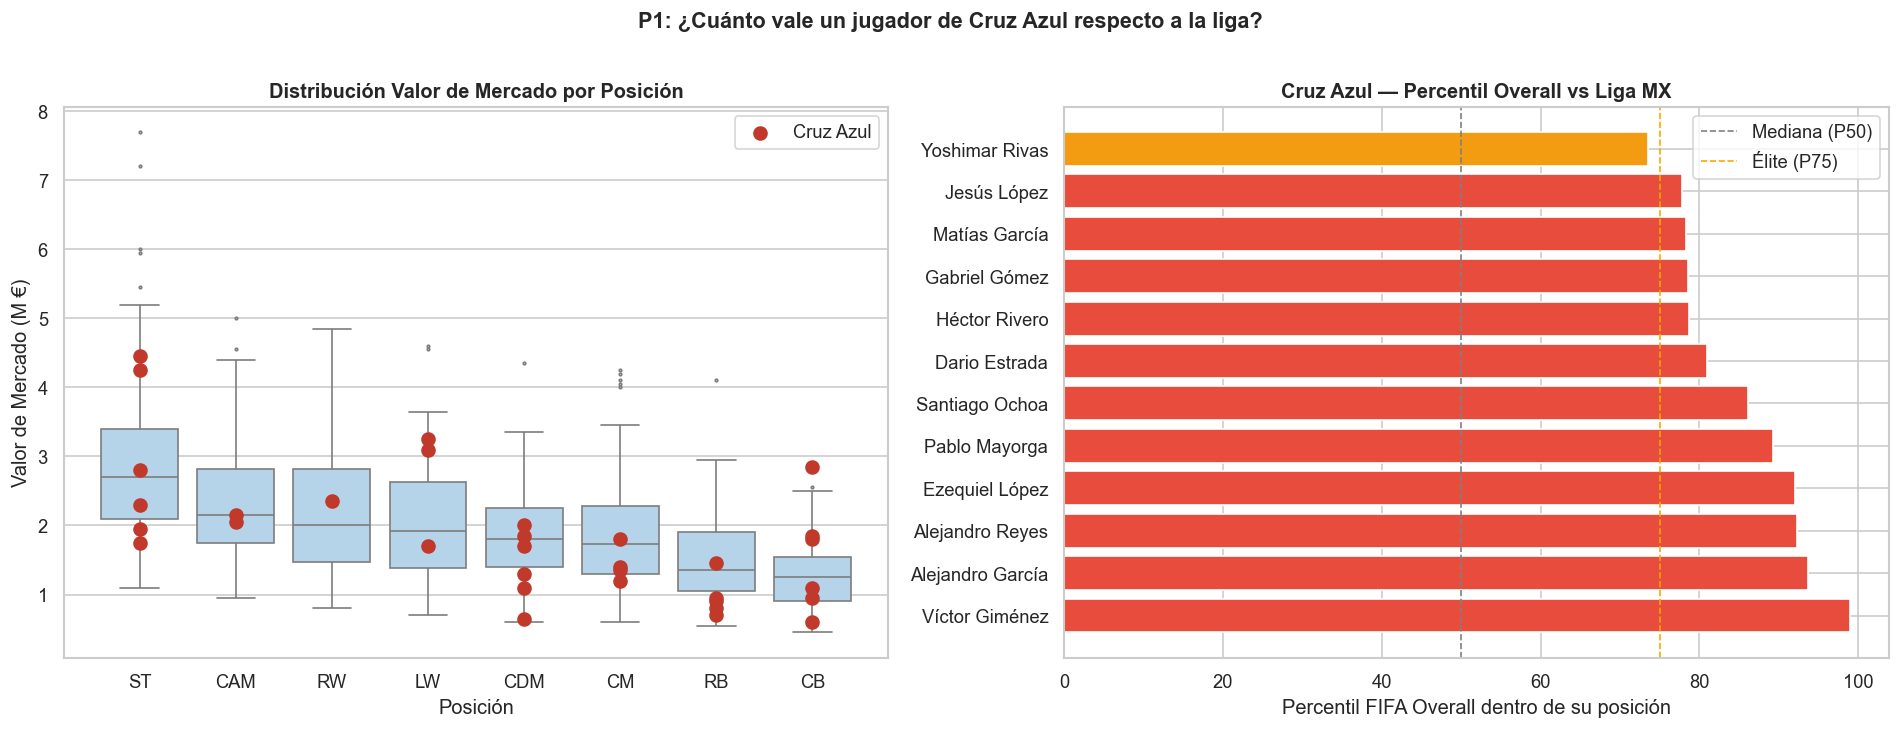


=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===
         Jugador Pos  Edad  Overall Valor Mercado  Percentil
  Víctor Giménez  LW    35       84     EUR 3.1 M       98.9
Alejandro García  CM    32       83           N/A       93.7
 Alejandro Reyes  SS    33       83    EUR 3.35 M       92.3
  Ezequiel López  LW    34       82     EUR 1.7 M       92.0
   Pablo Mayorga  CM    33       82     EUR 1.4 M       89.2
  Santiago Ochoa  RB    36       81    EUR 0.95 M       86.1
   Dario Estrada  GK    25       83    EUR 1.75 M       81.0
   Héctor Rivero  ST    25       78           N/A       78.7
   Gabriel Gómez  LM    31       78     EUR 2.4 M       78.5
   Matías García  LB    23       79     EUR 1.8 M       78.3
     Jesús López  GK    17       82     EUR 1.1 M       77.8
  Yoshimar Rivas CDM    36       78     EUR 1.3 M       73.5
Santiago Vázquez  CB    26       79     EUR 1.8 M       73.3
Héctor Fernández  LW    22       76    EUR 3.25 M       70.5
    Diego García CDM    20       77 

In [17]:
# P1 — Valor relativo de jugadores Cruz Azul
df_v = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()
df_v['vm_m'] = df_v['valor_mercado_eur'] / 1e6

top_pos = df_v['posicion'].value_counts().head(8).index.tolist()
df_v8   = df_v[df_v['posicion'].isin(top_pos)]
ca_v    = df_v8[es_ca(df_v8['equipo_norm'])]

order = df_v8.groupby('posicion')['vm_m'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Boxplot valor de mercado
ax = axes[0]
sns.boxplot(data=df_v8, x='posicion', y='vm_m', order=order,
            color='#AED6F1', fliersize=1.5, ax=ax)
added_label = False
for _, row in ca_v.iterrows():
    if row['posicion'] in order:
        idx = order.index(row['posicion'])
        label = 'Cruz Azul' if not added_label else ''
        ax.scatter(idx, row['vm_m'], color='#C0392B', s=60, zorder=5, label=label)
        added_label = True
ax.set_title('Distribución Valor de Mercado por Posición', fontweight='bold')
ax.set_xlabel('Posición')
ax.set_ylabel('Valor de Mercado (M €)')
ax.legend(loc='upper right')

# ── Percentil FIFA Overall de jugadores Cruz Azul
df_ov = df[df['fifa_overall'].notna()].copy()
ca_ov = df_ov[es_ca(df_ov['equipo_norm'])].copy()

def calc_percentil(row, ref):
    peers = ref.loc[ref['posicion'] == row['posicion'], 'fifa_overall'].dropna()
    return round((peers < row['fifa_overall']).mean() * 100, 1) if len(peers) > 1 else np.nan

ca_ov['pctil'] = ca_ov.apply(lambda r: calc_percentil(r, df_ov), axis=1)
top12 = ca_ov.nlargest(12, 'pctil')[['nombre_canonico', 'posicion', 'fifa_overall', 'pctil']].dropna()

ax2 = axes[1]
colors = ['#E74C3C' if p >= 75 else '#F39C12' if p >= 50 else '#3498DB'
          for p in top12['pctil']]
ax2.barh(top12['nombre_canonico'], top12['pctil'], color=colors)
ax2.axvline(50, color='gray', ls='--', lw=1, label='Mediana (P50)')
ax2.axvline(75, color='orange', ls='--', lw=1, label='Élite (P75)')
ax2.set_xlabel('Percentil FIFA Overall dentro de su posición')
ax2.set_title('Cruz Azul — Percentil Overall vs Liga MX', fontweight='bold')
ax2.legend()

fig.suptitle('P1: ¿Cuánto vale un jugador de Cruz Azul respecto a la liga?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Tabla resumen
print('\n=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===')
tabla = ca_ov[['nombre_canonico', 'posicion', 'edad', 'fifa_overall',
               'valor_mercado_eur', 'pctil']].dropna(subset=['pctil'])
tabla = tabla.sort_values('pctil', ascending=False).copy()
tabla['valor_mercado_eur'] = tabla['valor_mercado_eur'].apply(
    lambda x: ('EUR ' + str(round(x / 1e6, 2)) + ' M') if pd.notna(x) else 'N/A')
tabla.columns = ['Jugador', 'Pos', 'Edad', 'Overall', 'Valor Mercado', 'Percentil']
print(tabla.head(15).to_string(index=False))

---
## P2 — ¿Cómo ha evolucionado el valor de mercado total de la plantilla temporada a temporada?
> **Método:** Serie de tiempo del valor acumulado de plantilla por temporada para Cruz Azul, América y Rayados. Variación porcentual entre temporadas.  
> **Visualización:** Líneas de tiempo superpuestas + barras de variación porcentual.

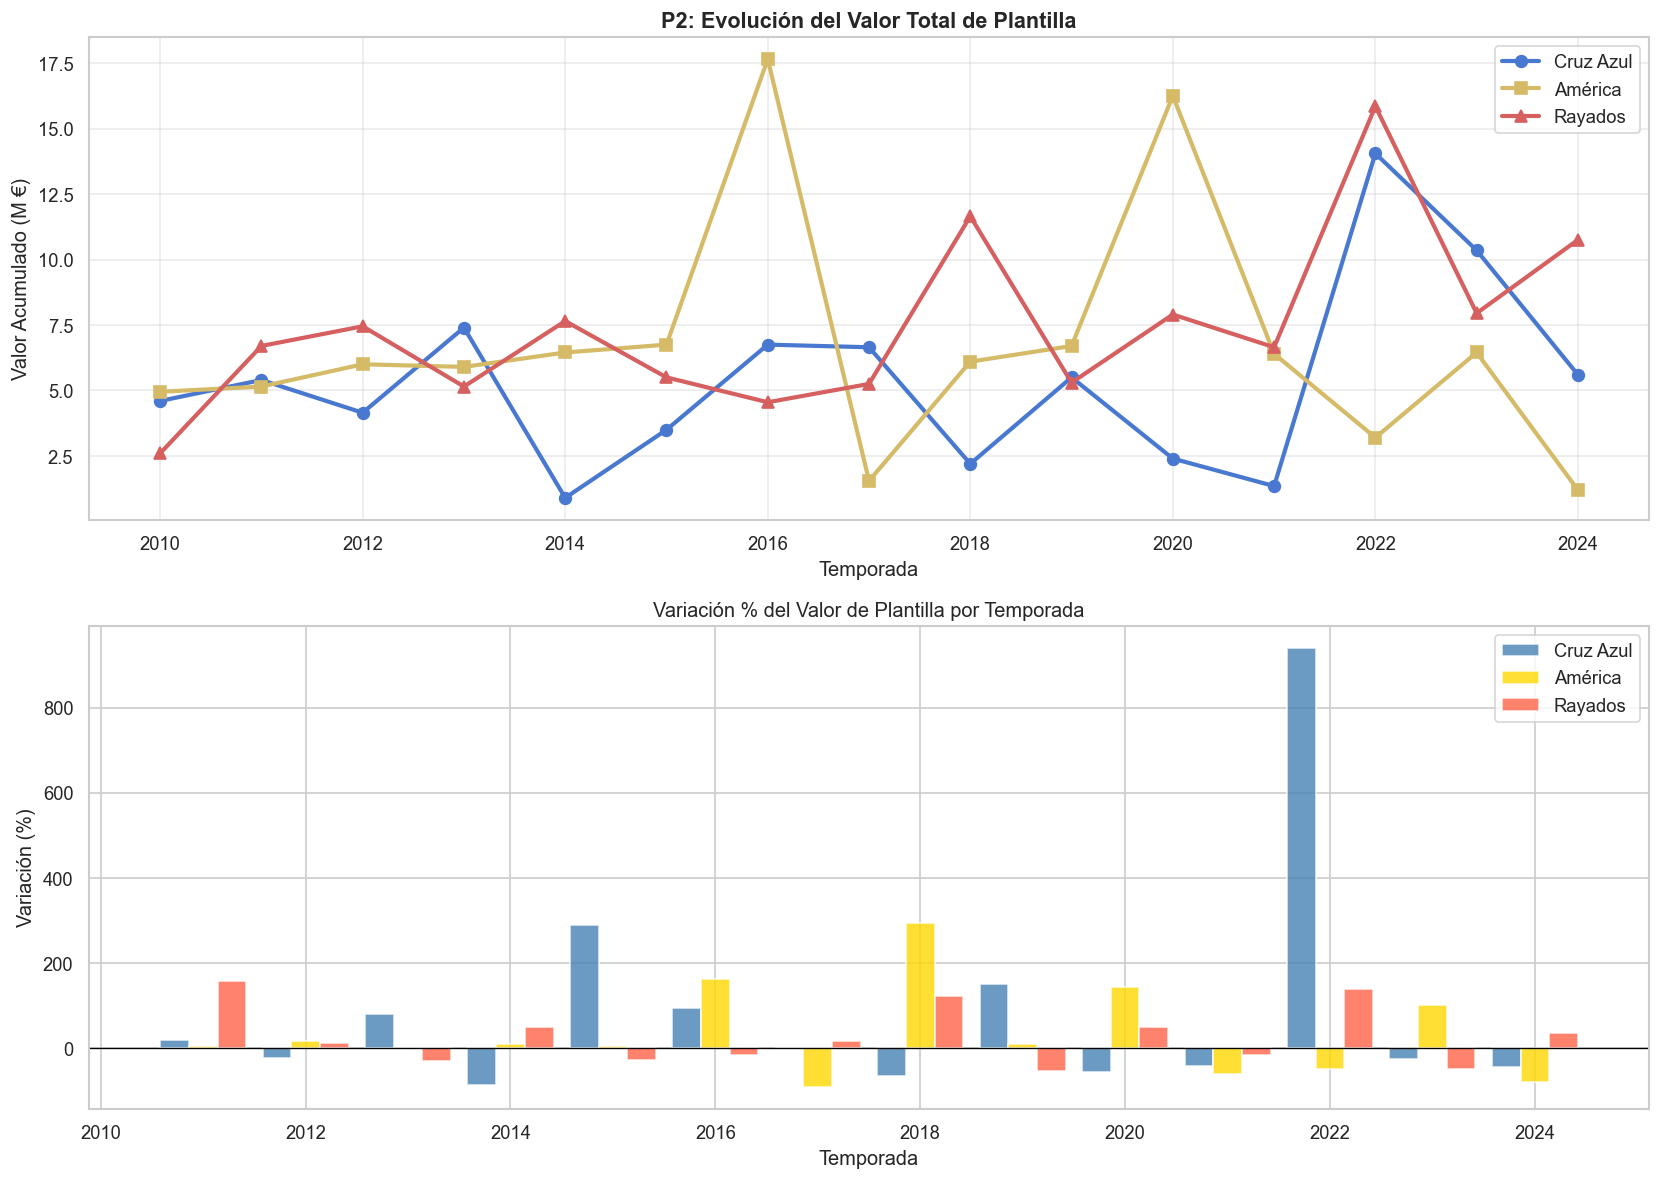


=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===
             Cruz Azul  América  Rayados
season_year                             
2010               4.6      5.0      2.6
2011               5.4      5.2      6.7
2012               4.2      6.0      7.4
2013               7.4      5.9      5.2
2014               0.9      6.4      7.6
2015               3.5      6.8      5.5
2016               6.8     17.6      4.6
2017               6.6      1.6      5.2
2018               2.2      6.1     11.6
2019               5.5      6.7      5.3
2020               2.4     16.2      7.9
2021               1.4      6.4      6.6
2022              14.0      3.2     15.8
2023              10.4      6.4      8.0
2024               5.6      1.2     10.8

=== VARIACIÓN PORCENTUAL ===
             Cruz Azul  América  Rayados
season_year                             
2011              17.4      4.0    157.7
2012             -23.1     16.5     11.2
2013              78.3     -1.7    -30.9
2014        

In [18]:
# P2 — Evolución del valor de mercado total de plantilla
df_p2 = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()

def valor_por_temporada(mask):
    return df_p2[mask].groupby('season_year')['valor_mercado_eur'].sum() / 1e6

ca_val  = valor_por_temporada(es_ca(df_p2['equipo_norm']))
am_val  = valor_por_temporada(es_am(df_p2['equipo_norm']))
ray_val = valor_por_temporada(es_ray(df_p2['equipo_norm']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Serie de tiempo
ax1.plot(ca_val.index,  ca_val.values,  'b-o', label='Cruz Azul', lw=2.5, ms=7)
ax1.plot(am_val.index,  am_val.values,  'y-s', label='América',   lw=2.5, ms=7)
ax1.plot(ray_val.index, ray_val.values, 'r-^', label='Rayados',   lw=2.5, ms=7)
ax1.set_title('P2: Evolución del Valor Total de Plantilla', fontsize=13, fontweight='bold')
ax1.set_xlabel('Temporada')
ax1.set_ylabel('Valor Acumulado (M €)')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Variación porcentual
ca_pct  = ca_val.pct_change() * 100
am_pct  = am_val.pct_change() * 100
ray_pct = ray_val.pct_change() * 100

w = 0.28
idx_ca  = ca_pct.dropna().index
idx_am  = am_pct.dropna().index
idx_ray = ray_pct.dropna().index

ax2.bar(ca_pct.dropna().index - w, ca_pct.dropna().values, w,
        label='Cruz Azul', color='steelblue', alpha=0.8)
ax2.bar(am_pct.dropna().index,     am_pct.dropna().values, w,
        label='América',   color='gold', alpha=0.8)
ax2.bar(ray_pct.dropna().index + w, ray_pct.dropna().values, w,
        label='Rayados',   color='tomato', alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Variación % del Valor de Plantilla por Temporada', fontsize=12)
ax2.set_xlabel('Temporada')
ax2.set_ylabel('Variación (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print('\n=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===')
resumen = pd.DataFrame({'Cruz Azul': ca_val, 'América': am_val, 'Rayados': ray_val})
print(resumen.round(1).to_string())

print('\n=== VARIACIÓN PORCENTUAL ===')
resumen_pct = pd.DataFrame({'Cruz Azul': ca_pct, 'América': am_pct, 'Rayados': ray_pct})
print(resumen_pct.round(1).dropna().to_string())

---
## P3 — ¿Cruz Azul rinde mejor en casa que fuera? ¿Cómo se compara con la liga?
> **Método:** Puntos por partido (PPP) en casa y fuera para cada equipo. Ranking de ventaja local.  
> **Visualización:** Barras agrupadas (casa vs fuera) + ranking de ventaja local.

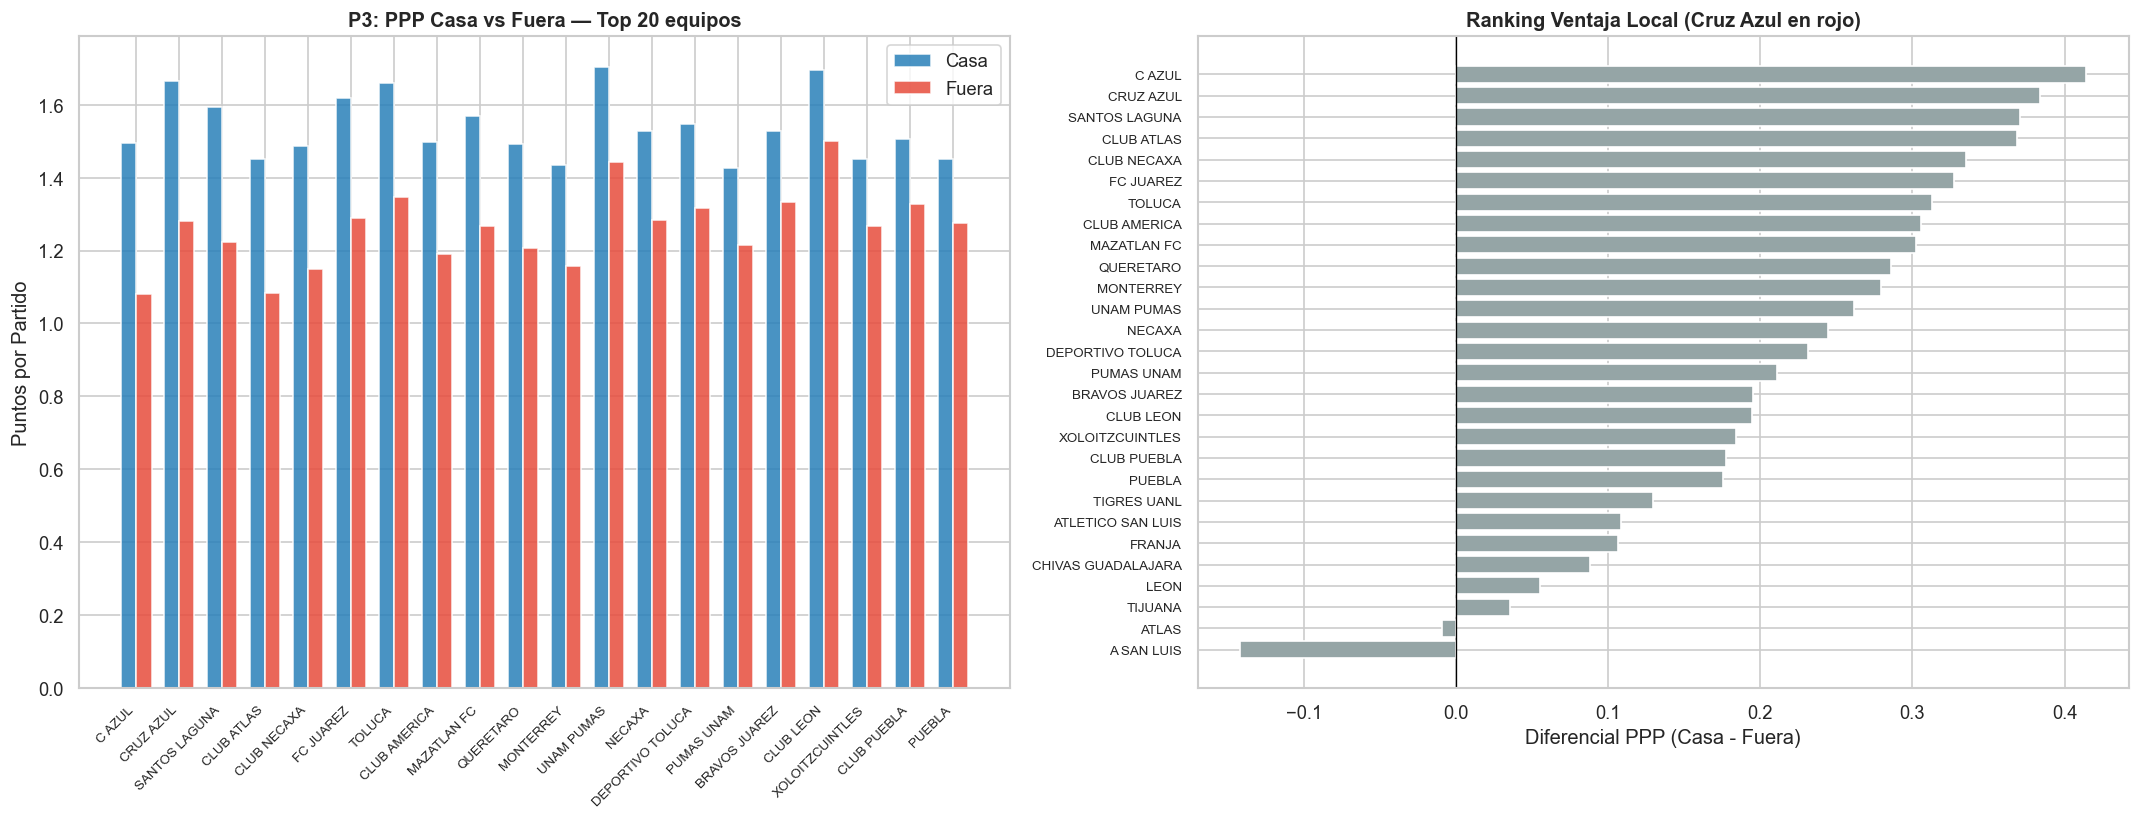

In [19]:
# P3 — Rendimiento en casa vs fuera

def puntos_local(res):
    if res == 'W': return 3
    if res == 'D': return 1
    return 0

def puntos_visitante(res):
    if res == 'L': return 3
    if res == 'D': return 1
    return 0

partidos_clean = partidos[partidos['resultado_local'].isin(['W', 'D', 'L'])].copy()
partidos_clean['pts_local']     = partidos_clean['resultado_local'].map(puntos_local)
partidos_clean['pts_visitante'] = partidos_clean['resultado_local'].map(puntos_visitante)

ppp_home = (partidos_clean.groupby('equipo_local_norm')['pts_local']
            .mean().rename('Casa'))
ppp_away = (partidos_clean.groupby('equipo_visitante_norm')['pts_visitante']
            .mean().rename('Fuera'))

ventaja = pd.concat([ppp_home, ppp_away], axis=1).dropna()
ventaja['Ventaja'] = ventaja['Casa'] - ventaja['Fuera']
ventaja = ventaja.sort_values('Ventaja', ascending=False)

# ── Posición Cruz Azul
ca_teams = [t for t in ventaja.index if 'Cruz' in str(t)]
if ca_teams:
    ca_team  = ca_teams[0]
    ca_rank  = int(ventaja['Ventaja'].rank(ascending=False)[ca_team])
    n_eq_p3  = len(ventaja)
    print('Cruz Azul PPP Casa :', round(ventaja.loc[ca_team, 'Casa'], 3))
    print('Cruz Azul PPP Fuera:', round(ventaja.loc[ca_team, 'Fuera'], 3))
    print('Ventaja Local      :', round(ventaja.loc[ca_team, 'Ventaja'], 3))
    print('Ranking en liga    :', ca_rank, 'de', n_eq_p3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ── Barras agrupadas top 20
top20 = ventaja.head(20)
x = np.arange(len(top20))
w = 0.35
bar_h = ax1.bar(x - w/2, top20['Casa'],  w, label='Casa',  color='#2980B9', alpha=0.85)
bar_a = ax1.bar(x + w/2, top20['Fuera'], w, label='Fuera', color='#E74C3C', alpha=0.85)
for i, team in enumerate(top20.index):
    if 'Cruz' in str(team):
        ax1.bar(i - w/2, top20.loc[team, 'Casa'],  w, color='navy',    alpha=1.0)
        ax1.bar(i + w/2, top20.loc[team, 'Fuera'], w, color='darkred', alpha=1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
ax1.set_title('P3: PPP Casa vs Fuera — Top 20 equipos', fontweight='bold')
ax1.set_ylabel('Puntos por Partido')
ax1.legend()

# ── Ranking ventaja local (todos los equipos)
v_sorted = ventaja.sort_values('Ventaja', ascending=True)
bar_colors = ['#E74C3C' if 'Cruz' in str(t) else '#95A5A6' for t in v_sorted.index]
ax2.barh(range(len(v_sorted)), v_sorted['Ventaja'], color=bar_colors)
ax2.set_yticks(range(len(v_sorted)))
ax2.set_yticklabels(v_sorted.index, fontsize=8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Ranking Ventaja Local (Cruz Azul en rojo)', fontweight='bold')
ax2.set_xlabel('Diferencial PPP (Casa - Fuera)')

plt.tight_layout()
plt.show()

# ── Análisis por Apertura / Clausura
if 'half' in partidos_clean.columns:
    for torneo in ['Apertura', 'Clausura']:
        sub = partidos_clean[partidos_clean['season'].str.contains(torneo, na=False)]
        if len(sub) > 0 and ca_teams:
            h_ca = sub[sub['equipo_local_norm'] == ca_team]['pts_local'].mean()
            a_ca = sub[sub['equipo_visitante_norm'] == ca_team]['pts_visitante'].mean()
            print(torneo, '— Casa:', round(h_ca, 3), '| Fuera:', round(a_ca, 3))

---
## P4 — ¿Cuáles son las métricas de los jugadores extranjeros vs nacionales de Cruz Azul?
> **Método:** Comparar valor de mercado, FIFA Overall y G+A/90 entre extranjeros y nacionales en Cruz Azul; contrastar con la liga.  
> **Visualización:** Donut de composición + barras comparativas.

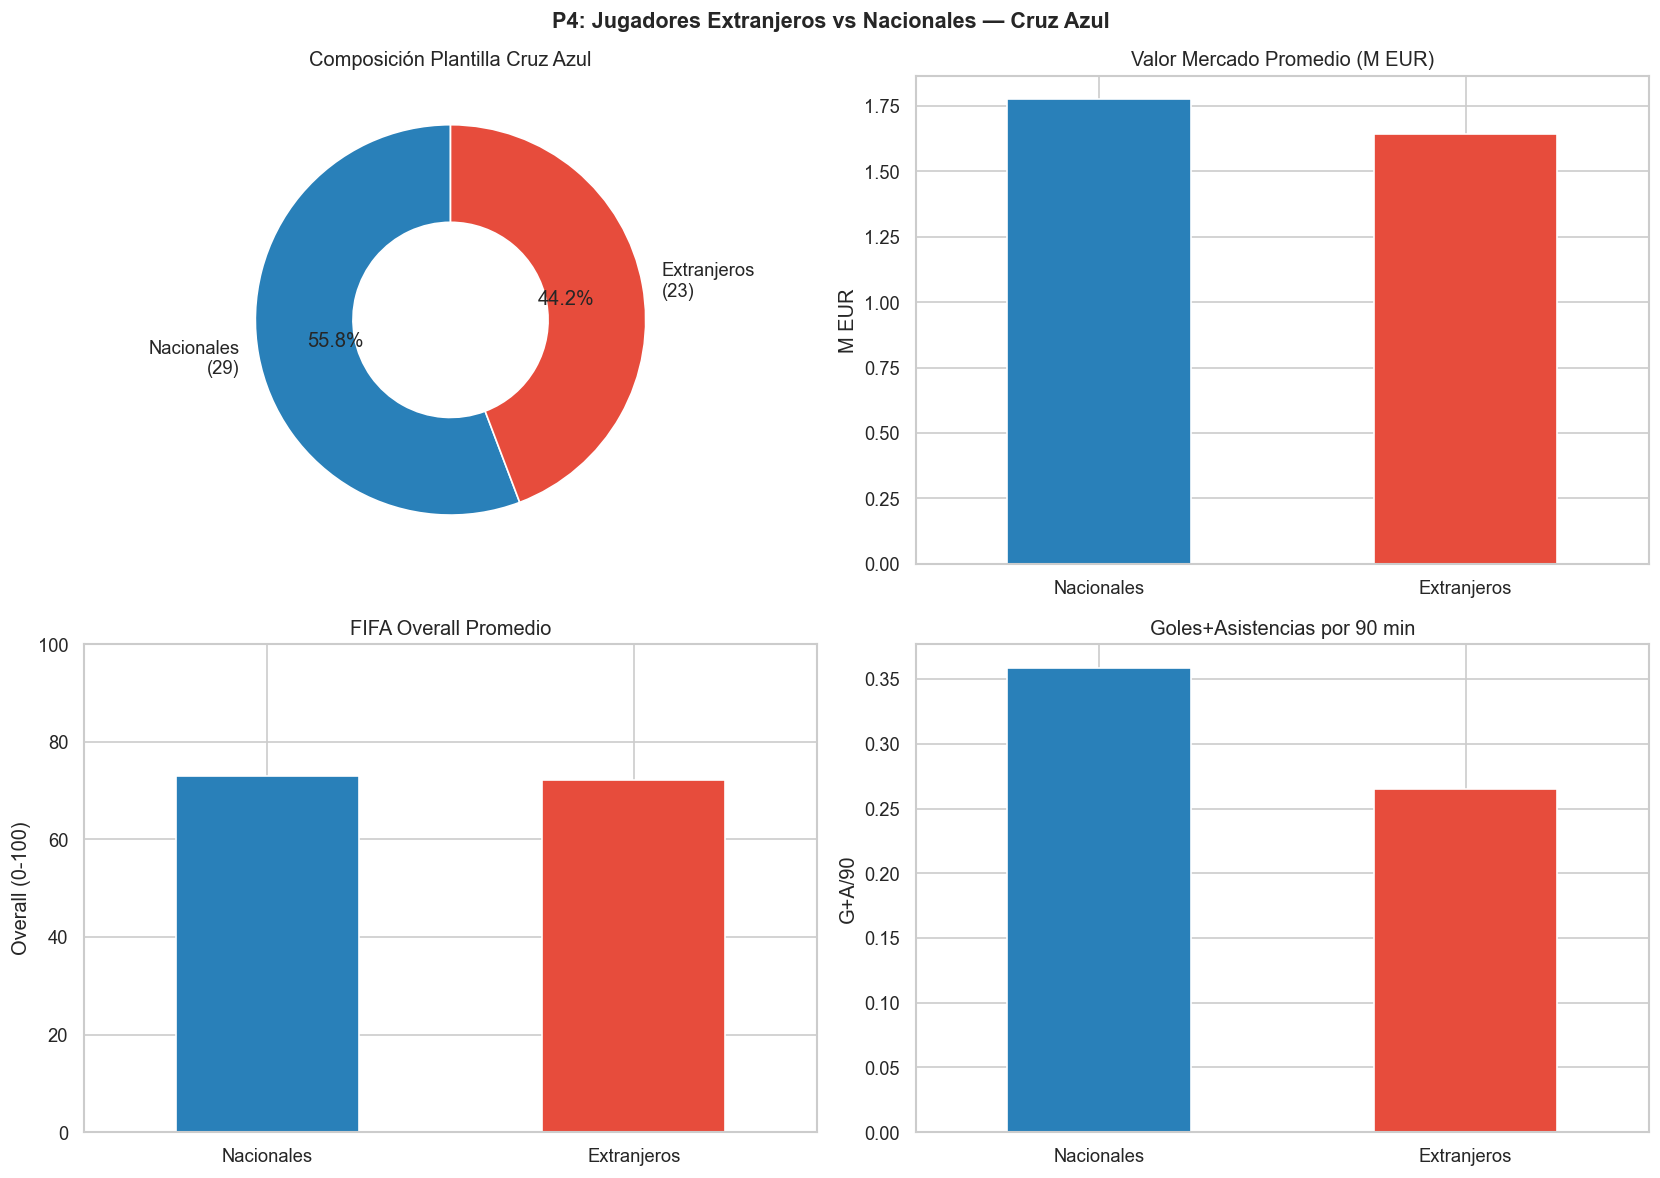


=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===
                      n  overall  valor_m  ga90
posicion extran                                
CAM      Nacionales   1    66.00     2.15  3.05
         Extranjeros  1    69.00     2.05  0.00
CB       Nacionales   4    71.75     1.30  0.13
         Extranjeros  2    73.00     1.98  0.16
CDM      Nacionales   3    70.67     1.50  0.20
         Extranjeros  3    71.33     1.37  0.41
CM       Nacionales   3    78.67     1.60  0.21
         Extranjeros  3    66.67     1.27  0.09
GK       Nacionales   4    78.50     1.19  0.07
         Extranjeros  2    79.50     1.42  0.21
LB       Nacionales   2    66.50     0.82  0.20
         Extranjeros  1    79.00     1.80  0.00
LM       Extranjeros  1    78.00     2.40  0.36
LW       Nacionales   1    84.00     3.10  0.13
         Extranjeros  3    76.33     2.48  0.59
RB       Nacionales   2    72.50     0.92  0.08
         Extranjeros  3    70.67     0.98  0.17
RM       Nacionales   2    66.50  

In [20]:
# P4 — Extranjeros vs nacionales
CA4 = df[es_ca(df['equipo_norm'])].copy()
CA4['extran'] = CA4['es_extranjero'].fillna(False)

ext_count = int(CA4['extran'].sum())
nac_count = int((~CA4['extran']).sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Donut composición
ax = axes[0, 0]
ax.pie([nac_count, ext_count],
       labels=[f'Nacionales\n({nac_count})', f'Extranjeros\n({ext_count})'],
       colors=['#2980B9', '#E74C3C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(width=0.5))
ax.set_title('Composición Plantilla Cruz Azul')

def media_seg(df_in, col):
    return df_in.groupby('extran')[col].mean()

def plot_bar_p4(ax, serie, title, ylabel, fmt=None):
    serie.index = ['Nacionales', 'Extranjeros']
    serie.plot(kind='bar', ax=ax, color=['#2980B9', '#E74C3C'], rot=0)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

# ── Valor mercado promedio
vm_ser = (CA4.groupby('extran')['valor_mercado_eur']
          .mean().fillna(0) / 1e6)
plot_bar_p4(axes[0, 1], vm_ser, 'Valor Mercado Promedio (M EUR)', 'M EUR')

# ── FIFA Overall promedio
ov_ser = media_seg(CA4, 'fifa_overall').fillna(0)
plot_bar_p4(axes[1, 0], ov_ser, 'FIFA Overall Promedio', 'Overall (0-100)')
axes[1, 0].set_ylim(0, 100)

# ── G+A por 90 min
ga_ser = media_seg(CA4, 'g_a_por_90').fillna(0)
plot_bar_p4(axes[1, 1], ga_ser, 'Goles+Asistencias por 90 min', 'G+A/90')

fig.suptitle('P4: Jugadores Extranjeros vs Nacionales — Cruz Azul',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabla comparativa por posición
print('\n=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===')
tabla_pos = CA4.groupby(['posicion', 'extran']).agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
tabla_pos.index = tabla_pos.index.set_levels(
    ['Nacionales', 'Extranjeros'], level=1)
print(tabla_pos.to_string())

# ── Comparativa vs liga
print('\n=== LIGA MX: EXTRANJEROS vs NACIONALES ===')
liga_comp = df.copy()
liga_comp['extran'] = liga_comp['es_extranjero'].fillna(False)
liga_agg = liga_comp.groupby('extran').agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.dropna().mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
liga_agg.index = ['Nacionales', 'Extranjeros']
print(liga_agg.to_string())

---
## P5 — ¿Qué equipos presentan mayor brecha entre valoración FIFA y valor Transfermarkt?
> **Método:** Normalizar FIFA Overall y log(Valor TM) a rango 0-1. Calcular brecha = FIFA_norm − TM_norm. Agregar por equipo.  
> **Visualización:** Scatter FIFA vs TM + ranking de 'talento oculto' por equipo.

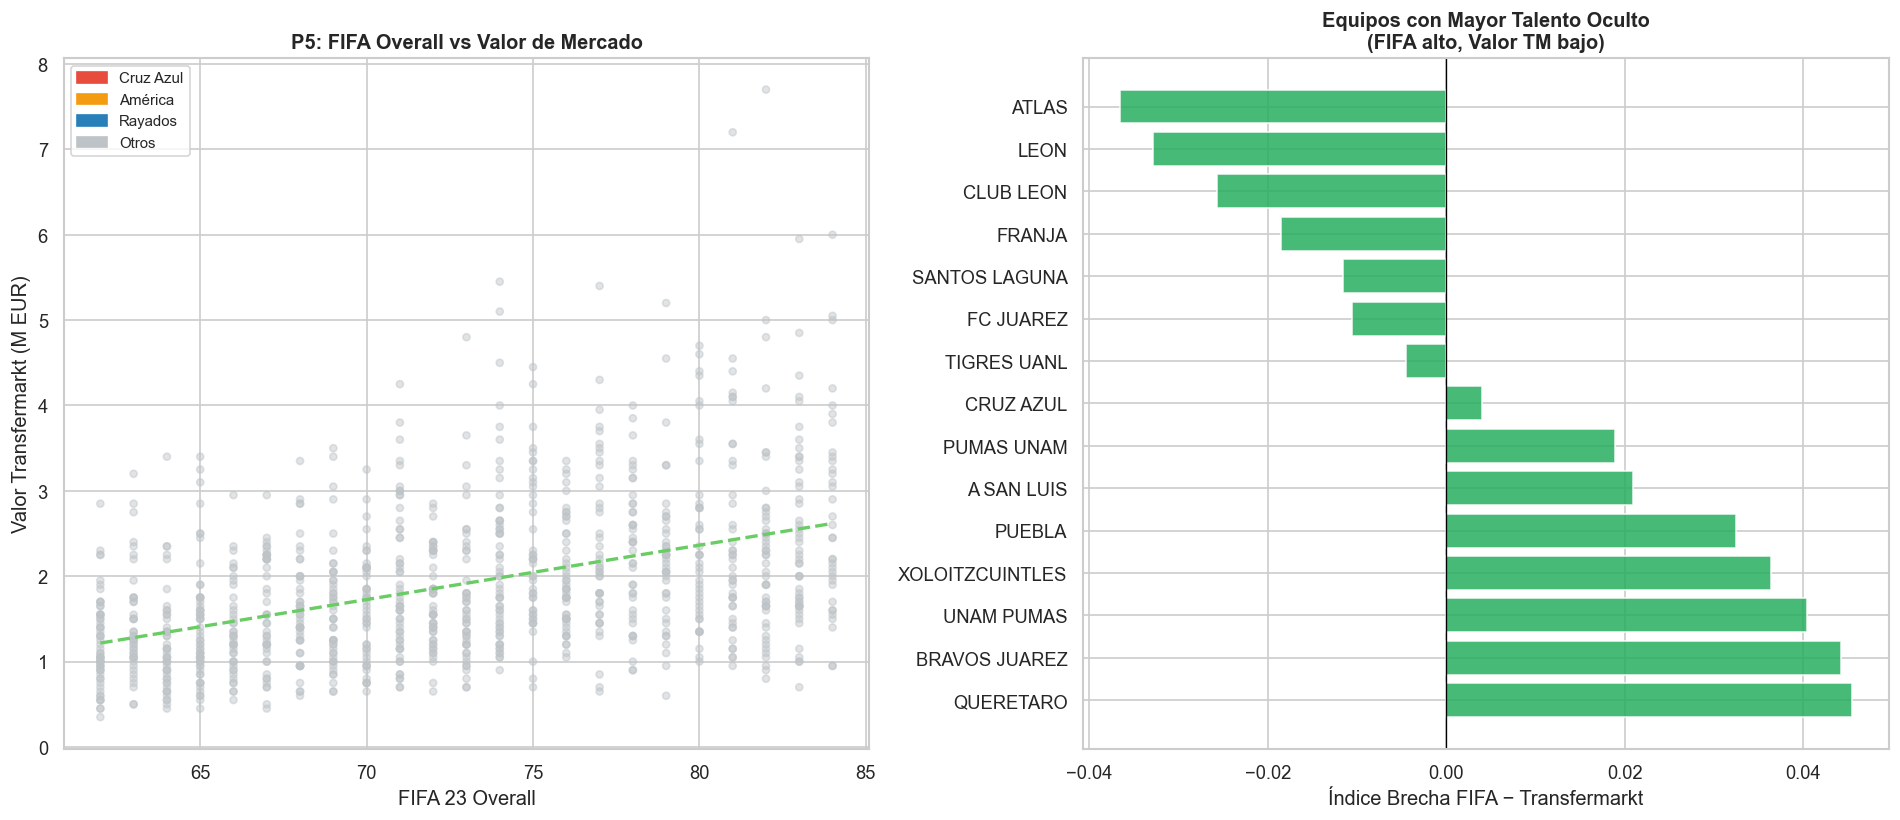


=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===
    equipo_norm  brecha_media  n  overall_prom  vm_prom
      QUERETARO         0.045 68        74.544    1.906
  BRAVOS JUAREZ         0.044 24        73.167    1.610
     UNAM PUMAS         0.040 21        74.857    2.145
XOLOITZCUINTLES         0.036 23        73.696    1.865
         PUEBLA         0.032 19        72.316    1.508
     A SAN LUIS         0.021 20        72.950    1.678
     PUMAS UNAM         0.019 22        74.000    2.011
      CRUZ AZUL         0.004 47        72.553    1.719
    TIGRES UANL        -0.005 70        73.357    2.014
      FC JUAREZ        -0.011 49        73.163    1.958

=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===
    nombre_canonico   equipo_norm posicion  fifa_overall  valor_mercado_eur  brecha
Sebastián Rodríguez BRAVOS JUAREZ       GK            83               0.70   0.730
     Fernando Ochoa          LEON       CB            84               0.95   0.677
      Rodrigo Pérez     QU

In [21]:
# P5 — Brecha FIFA vs Transfermarkt (talento oculto)
df_p5 = df[df['valor_mercado_eur'].notna() &
           df['fifa_overall'].notna() &
           (df['valor_mercado_eur'] > 0)].copy()

scaler = MinMaxScaler()
df_p5['ov_norm'] = scaler.fit_transform(df_p5[['fifa_overall']])
log_val = np.log1p(df_p5['valor_mercado_eur']).values.reshape(-1, 1)
df_p5['vm_norm'] = scaler.fit_transform(log_val)
df_p5['brecha']  = df_p5['ov_norm'] - df_p5['vm_norm']  # + = FIFA alto, TM bajo → subvalorado

# ── Por equipo
team_brecha = (df_p5.groupby('equipo_norm')
               .agg(brecha_media=('brecha', 'mean'),
                    n=('nombre_canonico', 'count'),
                    overall_prom=('fifa_overall', 'mean'),
                    vm_prom=('valor_mercado_eur', lambda x: x.mean() / 1e6))
               .reset_index())
team_brecha = team_brecha[team_brecha['n'] >= 5].sort_values('brecha_media', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Scatter: FIFA Overall vs Valor TM por jugador
def color_team(t):
    if 'Cruz' in str(t): return '#E74C3C'
    if 'América' in str(t) or 'America' in str(t): return '#F39C12'
    if 'Monterrey' in str(t) or 'Rayados' in str(t): return '#2980B9'
    return '#BDC3C7'

dot_colors = df_p5['equipo_norm'].apply(color_team)
ax1.scatter(df_p5['fifa_overall'], df_p5['valor_mercado_eur'] / 1e6,
            c=dot_colors, alpha=0.45, s=18)

z = np.polyfit(df_p5['fifa_overall'], df_p5['valor_mercado_eur'] / 1e6, 1)
x_line = np.linspace(df_p5['fifa_overall'].min(), df_p5['fifa_overall'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), 'g--', lw=2, label='Tendencia liga')
ax1.set_xlabel('FIFA 23 Overall')
ax1.set_ylabel('Valor Transfermarkt (M EUR)')
ax1.set_title('P5: FIFA Overall vs Valor de Mercado', fontweight='bold')
legend_elem = [
    mpatches.Patch(color='#E74C3C', label='Cruz Azul'),
    mpatches.Patch(color='#F39C12', label='América'),
    mpatches.Patch(color='#2980B9', label='Rayados'),
    mpatches.Patch(color='#BDC3C7', label='Otros'),
]
ax1.legend(handles=legend_elem, fontsize=9)

# ── Ranking de brecha por equipo
top_b = team_brecha.head(15)
bar_bc = ['#E74C3C' if 'Cruz' in str(t) else '#27AE60' for t in top_b['equipo_norm']]
ax2.barh(top_b['equipo_norm'], top_b['brecha_media'], color=bar_bc, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Equipos con Mayor Talento Oculto\n(FIFA alto, Valor TM bajo)', fontweight='bold')
ax2.set_xlabel('Índice Brecha FIFA − Transfermarkt')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===')
print(team_brecha[['equipo_norm', 'brecha_media', 'n', 'overall_prom', 'vm_prom']]
      .head(10).round(3).to_string(index=False))

# ── Top 10 jugadores subvalorados en Liga MX
top_jug = df_p5.nlargest(10, 'brecha')[['nombre_canonico', 'equipo_norm',
                                          'posicion', 'fifa_overall',
                                          'valor_mercado_eur', 'brecha']].copy()
top_jug['valor_mercado_eur'] = top_jug['valor_mercado_eur'] / 1e6
print('\n=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===')
print(top_jug.round(3).to_string(index=False))

---
## P6 — ¿Qué jugadores de Liga MX tienen mayor probabilidad de ser transferidos?
> **Método:** Modelo Random Forest. Target: cambio de equipo entre temporadas consecutivas. Features: edad, overall, valor mercado, goles, asistencias, minutos, G+A/90.  
> **Evaluación:** AUC-ROC + Feature Importance.

Features usadas: ['edad', 'fifa_overall', 'valor_mercado_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90']
Distribución target — No Transferido: 797 | Transferido: 280
AUC-ROC en test: 0.4921


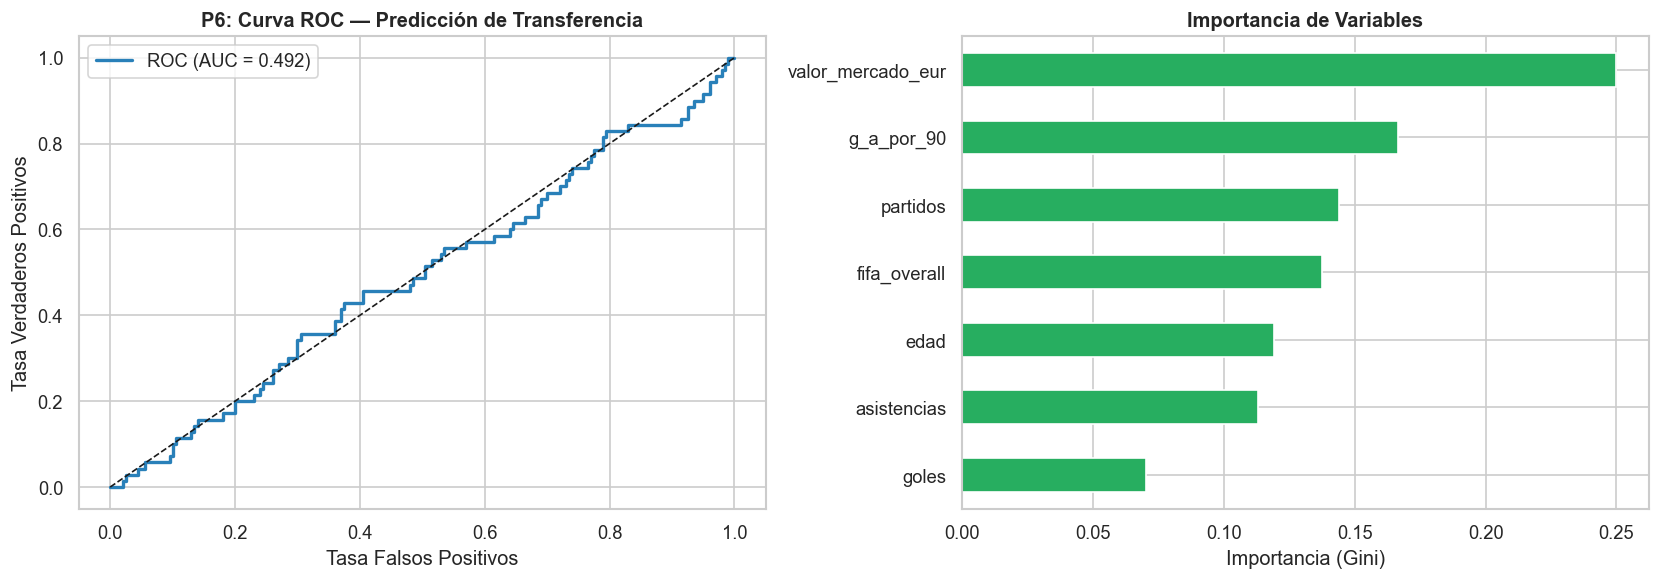


=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===
   nombre_canonico     equipo_norm posicion  prob_transfer
       Lucas Lotti     CLUB NECAXA       CM          0.633
     Pablo Vázquez      UNAM PUMAS      CDM          0.614
      Ramón Flores           ATLAS       CM          0.611
       Jesús López       CRUZ AZUL       GK          0.606
       André Pérez       QUERETARO       RB          0.597
     Matías Flores     TIGRES UANL       RW          0.596
 Guillermo Vázquez         TIJUANA       RM          0.594
      Lucas Suárez XOLOITZCUINTLES       RB          0.594
Alejandro Martínez     CLUB NECAXA       GK          0.589
    Uriel González       QUERETARO       GK          0.586
   Jonathan Castro   BRAVOS JUAREZ       RM          0.582
   César Hernández     MAZATLAN FC      CDM          0.579
     Marco Mayorga       FC JUAREZ       RB          0.577
   Sebastián Gómez   SANTOS LAGUNA       CB          0.576
  Alejandro Castro            LEON       CB      

In [22]:
# P6 — Probabilidad de transferencia (clasificación binaria)

# ── Crear target: ¿cambia de equipo en la siguiente temporada?
cols_p6 = ['nombre_key', 'season_year', 'equipo_norm', 'edad',
           'fifa_overall', 'valor_mercado_eur', 'goles',
           'asistencias', 'partidos', 'g_a_por_90', 'posicion',
           'nombre_canonico']
df_p6 = df[[c for c in cols_p6 if c in df.columns]].copy()
df_p6 = df_p6.sort_values(['nombre_key', 'season_year'])

df_p6['equipo_next'] = df_p6.groupby('nombre_key')['equipo_norm'].shift(-1)
df_p6['transferido'] = (
    df_p6['equipo_next'].notna() &
    (df_p6['equipo_norm'] != df_p6['equipo_next'])
).astype(int)

features = [f for f in ['edad', 'fifa_overall', 'valor_mercado_eur',
                         'goles', 'asistencias', 'partidos', 'g_a_por_90']
            if f in df_p6.columns]

ml_df = df_p6[features + ['transferido', 'nombre_canonico', 'equipo_norm',
                           'posicion']].dropna(subset=features + ['transferido'])

X = ml_df[features].values
y = ml_df['transferido'].values

print('Features usadas:', features)
print('Distribución target — No Transferido:', (y == 0).sum(), '| Transferido:', (y == 1).sum())

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                             class_weight='balanced')
rf.fit(X_tr, y_tr)
y_prob = rf.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print('AUC-ROC en test:', round(auc, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax1.plot(fpr, tpr, color='#2980B9', lw=2, label='ROC (AUC = ' + str(round(auc, 3)) + ')')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P6: Curva ROC — Predicción de Transferencia', fontweight='bold')
ax1.legend()

# ── Feature importance
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
imp.plot(kind='barh', ax=ax2, color='#27AE60')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

# ── Ranking de probabilidad de transferencia — última temporada por jugador
ml_df2 = df_p6[features + ['nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features)
ml_df2 = ml_df2.copy()
ml_df2['prob_transfer'] = rf.predict_proba(ml_df2[features].values)[:, 1]

last_idx = df_p6.sort_values('season_year').groupby('nombre_key').tail(1).index
candidates = ml_df2.loc[ml_df2.index.isin(last_idx)].sort_values(
    'prob_transfer', ascending=False)

print('\n=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===')
print(candidates[['nombre_canonico', 'equipo_norm', 'posicion', 'prob_transfer']]
      .head(15).round(3).to_string(index=False))

print('\n=== JUGADORES CRUZ AZUL — RANKING DE RIESGO ===')
ca_risk = candidates[es_ca(candidates['equipo_norm'])]
print(ca_risk[['nombre_canonico', 'posicion', 'prob_transfer']].head(10).round(3).to_string(index=False))

---
## P7 — ¿Cuál es el valor de mercado esperado dado el rendimiento real y atributos FIFA?
> **Método:** Gradient Boosting Regressor. Target: log(valor_mercado_eur). Features: overall, potential, edad, posición codificada, goles, asistencias, minutos.  
> **Evaluación:** RMSE, R² + scatter predicho vs real.

RMSE (log-escala): 0.2719
R²              : 0.6953


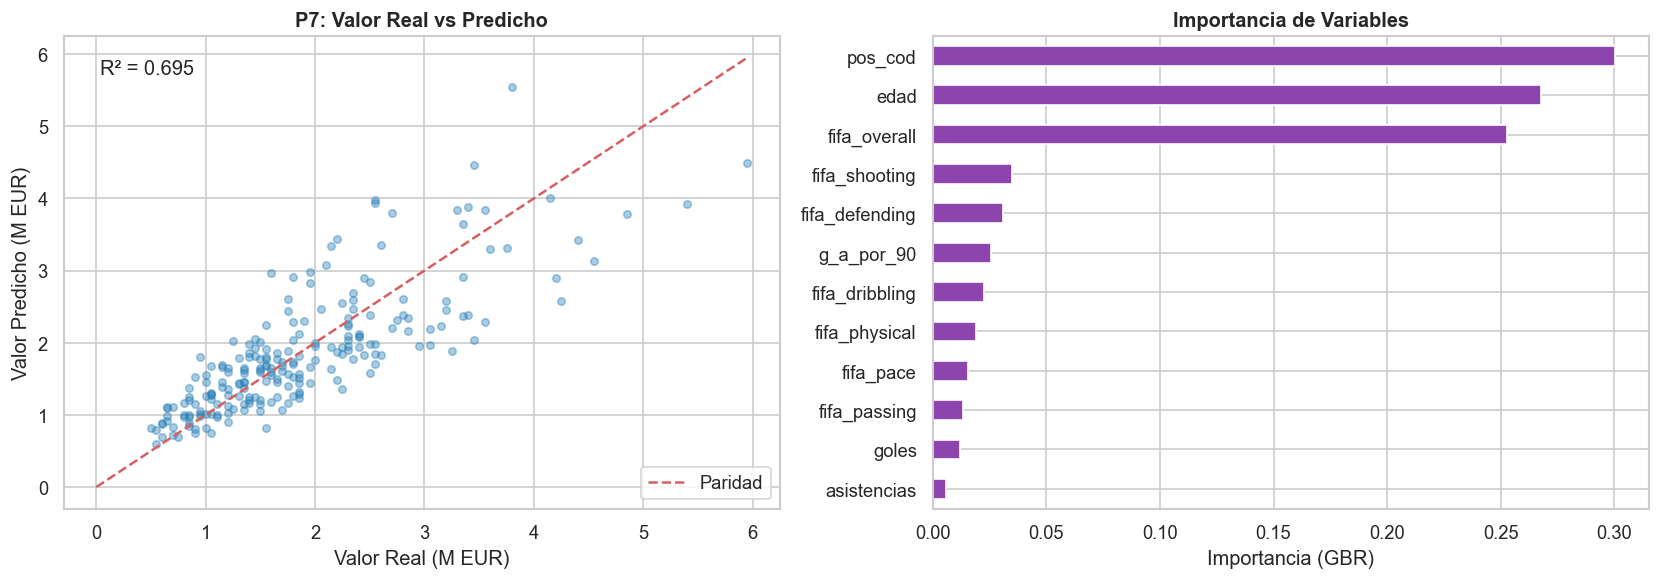


=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===
           Jugador Pos  Overall  Valor Real M  Valor Esperado M  Diferencia M
      Felipe Rivas  RM       66          1.00              1.55          0.55
     Matías García  LB       79          1.80              2.28          0.48
     Jonathan Mora  CM       74          1.20              1.60          0.40
       Luis Moreno  LB       68          0.60              0.89          0.29
      Pablo Torres  RB       71          0.70              0.96          0.26
      Hirving Romo  RM       66          1.35              1.58          0.23
     Pablo Mayorga  CM       82          1.40              1.62          0.22
   Erick Hernández  LB       65          1.05              1.25          0.20
   Nicolás Montoya  GK       76          1.10              1.29          0.19
     Ramón Vázquez  GK       78          0.90              1.08          0.18
    Dario Carneiro CDM       73          1.10              1.27          0.17
  André

In [23]:
# P7 — Valor de mercado esperado (regresión)
feats7 = ['fifa_overall', 'edad', 'goles', 'asistencias', 'minutos', 'g_a_por_90',
          'fifa_pace', 'fifa_shooting', 'fifa_passing',
          'fifa_dribbling', 'fifa_defending', 'fifa_physical']
feats7_present = [f for f in feats7 if f in df.columns]

df_p7 = df[feats7_present + ['valor_mercado_eur', 'posicion',
                              'nombre_canonico', 'equipo_norm']].copy()
df_p7 = df_p7[df_p7['valor_mercado_eur'].notna() & (df_p7['valor_mercado_eur'] > 0)].copy()

# Codificar posición
le = LabelEncoder()
df_p7['pos_cod'] = le.fit_transform(df_p7['posicion'].fillna('Unknown'))
features7 = feats7_present + ['pos_cod']

df_p7 = df_p7.dropna(subset=feats7_present)
df_p7['log_vm'] = np.log1p(df_p7['valor_mercado_eur'])

X7 = df_p7[features7].values
y7 = df_p7['log_vm'].values

X7_tr, X7_te, y7_tr, y7_te, idx7_tr, idx7_te = train_test_split(
    X7, y7, df_p7.index, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gbr.fit(X7_tr, y7_tr)
y7_pred = gbr.predict(X7_te)

rmse = np.sqrt(mean_squared_error(y7_te, y7_pred))
r2   = r2_score(y7_te, y7_pred)
print('RMSE (log-escala):', round(rmse, 4))
print('R²              :', round(r2, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter predicho vs real (escala original M EUR)
y7_real_m  = np.expm1(y7_te) / 1e6
y7_pred_m  = np.expm1(y7_pred) / 1e6
ax1.scatter(y7_real_m, y7_pred_m, alpha=0.4, s=20, color='#2980B9')
lim = max(y7_real_m.max(), y7_pred_m.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Paridad')
ax1.set_xlabel('Valor Real (M EUR)')
ax1.set_ylabel('Valor Predicho (M EUR)')
ax1.set_title('P7: Valor Real vs Predicho', fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, 'R² = ' + str(round(r2, 3)), transform=ax1.transAxes)

# ── Importancia de variables
imp7 = pd.Series(gbr.feature_importances_, index=features7).sort_values(ascending=True)
imp7.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (GBR)')

plt.tight_layout()
plt.show()

# ── Jugadores Cruz Azul: valor real vs esperado
ca_p7 = df_p7[es_ca(df_p7['equipo_norm'])].copy()
ca_p7['vm_esperado'] = np.expm1(gbr.predict(ca_p7[features7].values))
ca_p7['diferencia_m'] = (ca_p7['vm_esperado'] - ca_p7['valor_mercado_eur']) / 1e6
ca_p7['vm_real_m']    = ca_p7['valor_mercado_eur'] / 1e6
ca_p7['vm_esperado_m'] = ca_p7['vm_esperado'] / 1e6

print('\n=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===')
disp7 = ca_p7[['nombre_canonico', 'posicion', 'fifa_overall',
                'vm_real_m', 'vm_esperado_m', 'diferencia_m']].sort_values(
    'diferencia_m', ascending=False)
disp7.columns = ['Jugador', 'Pos', 'Overall', 'Valor Real M', 'Valor Esperado M', 'Diferencia M']
print(disp7.round(2).to_string(index=False))

---
## P8 — ¿Qué resultado puede esperarse en un partido de Cruz Azul?
> **Método:** Random Forest multiclase (V/E/D). Features: diferencial de Overall promedio entre plantillas, forma reciente (últimas 5 fechas), condición local/visitante.  
> **Evaluación:** Matriz de confusión + curvas ROC por clase.

=== MODELO P8: PREDICCIÓN DE RESULTADO ===
              precision    recall  f1-score   support

           D       0.24      0.35      0.29       189
           L       0.39      0.50      0.44       294
           W       0.45      0.23      0.31       358

    accuracy                           0.35       841
   macro avg       0.36      0.36      0.34       841
weighted avg       0.38      0.35      0.35       841



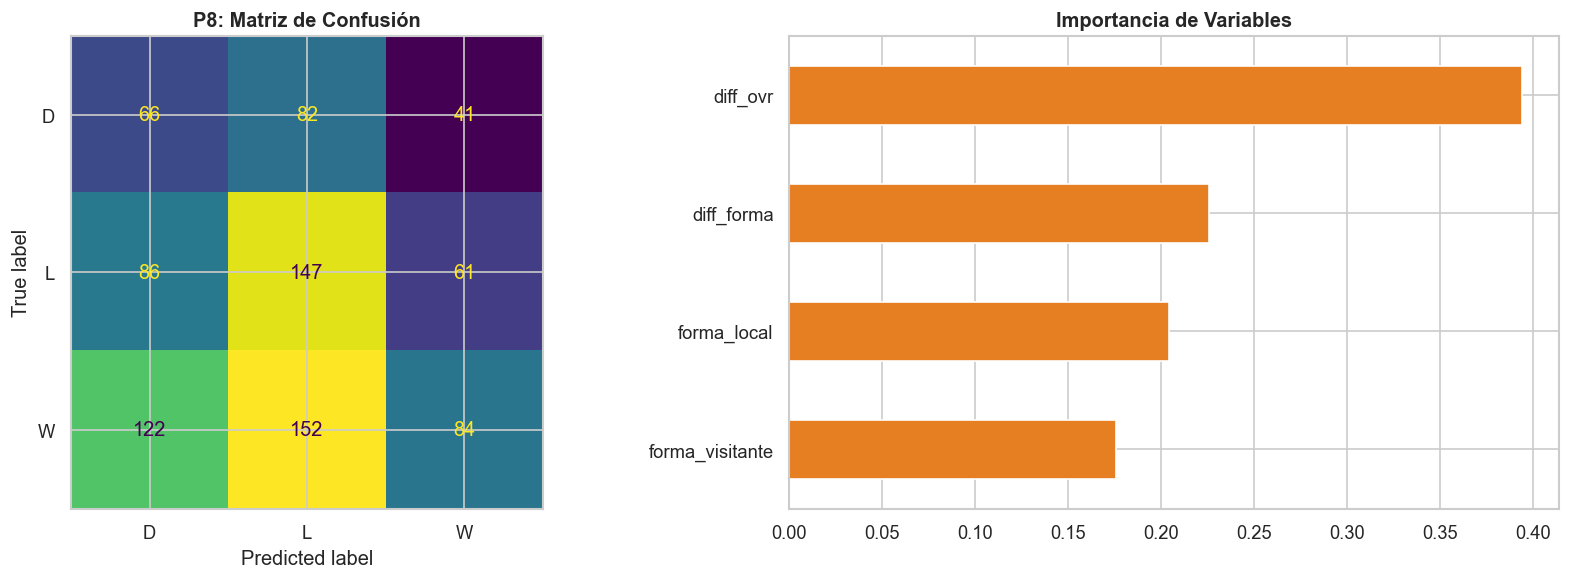


=== EJEMPLO: ÚLTIMO PARTIDO DE CRUZ AZUL ===
D : 37.8 %
L : 29.8 %
W : 32.4 %


In [24]:
# P8 — Predicción de resultado de partidos Cruz Azul

# ── Squad strength: Overall promedio por equipo y temporada
squad_str = (df[df['fifa_overall'].notna()]
             .groupby(['equipo_norm', 'season_year'])['fifa_overall']
             .mean().reset_index()
             .rename(columns={'fifa_overall': 'squad_overall'}))

pt = partidos.copy()
pt['season_year'] = pt['season_year'].astype('Int64')

pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_local_norm',
                                         'squad_overall': 'ovr_local'}),
              on=['equipo_local_norm', 'season_year'], how='left')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_visitante_norm',
                                         'squad_overall': 'ovr_visit'}),
              on=['equipo_visitante_norm', 'season_year'], how='left')
pt['diff_ovr'] = pt['ovr_local'] - pt['ovr_visit']

# ── Forma reciente (últimas 5 fechas) por equipo
pt_sorted = pt.sort_values('date').reset_index(drop=True)

def calcular_forma(team, match_date, n=5):
    prev = pt_sorted[pt_sorted['date'] < match_date]
    local_res = prev[prev['equipo_local_norm'] == team]['pts_local']
    visit_res = prev[prev['equipo_visitante_norm'] == team]['pts_visitante']
    hist = pd.concat([local_res, visit_res]).sort_index().tail(n)
    return hist.mean() if len(hist) > 0 else 1.0

pt_sorted['pts_local']     = pt_sorted['resultado_local'].map({'W': 3, 'D': 1, 'L': 0})
pt_sorted['pts_visitante'] = pt_sorted['resultado_local'].map({'W': 0, 'D': 1, 'L': 3})

pt_sorted['forma_local']   = [
    calcular_forma(row['equipo_local_norm'],    row['date'])
    for _, row in pt_sorted.iterrows()]
pt_sorted['forma_visitante'] = [
    calcular_forma(row['equipo_visitante_norm'], row['date'])
    for _, row in pt_sorted.iterrows()]

pt_sorted['diff_forma'] = pt_sorted['forma_local'] - pt_sorted['forma_visitante']

# ── Filtrar Cruz Azul (local o visitante) para análisis específico
ca_p8 = pt_sorted[es_ca(pt_sorted['equipo_local_norm']) |
                  es_ca(pt_sorted['equipo_visitante_norm'])].copy()
ca_p8['es_local'] = es_ca(ca_p8['equipo_local_norm']).astype(int)

# ── Modelo general (toda la liga)
feats8 = ['diff_ovr', 'forma_local', 'forma_visitante', 'diff_forma']
df_ml8 = pt_sorted[feats8 + ['resultado_local']].dropna()

le8 = LabelEncoder()
y8  = le8.fit_transform(df_ml8['resultado_local'])
X8  = df_ml8[feats8].values

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.25,
                                                random_state=42, stratify=y8)
rf8 = RandomForestClassifier(n_estimators=200, max_depth=5,
                              random_state=42, class_weight='balanced')
rf8.fit(X8_tr, y8_tr)
y8_pred = rf8.predict(X8_te)

print('=== MODELO P8: PREDICCIÓN DE RESULTADO ===')
print(classification_report(y8_te, y8_pred, target_names=le8.classes_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Matriz de confusión
cm8 = confusion_matrix(y8_te, y8_pred)
ConfusionMatrixDisplay(cm8, display_labels=le8.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P8: Matriz de Confusión', fontweight='bold')

# ── Importancia de variables
imp8 = pd.Series(rf8.feature_importances_, index=feats8).sort_values(ascending=True)
imp8.plot(kind='barh', ax=ax2, color='#E67E22')
ax2.set_title('Importancia de Variables', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Predicción de ejemplo: Cruz Azul vs rival hipotético
if len(ca_p8) > 0:
    sample = ca_p8[feats8].dropna().iloc[-1:]
    probs  = rf8.predict_proba(sample.values)[0]
    print('\n=== EJEMPLO: ÚLTIMO PARTIDO DE CRUZ AZUL ===')
    for cls, p in zip(le8.classes_, probs):
        print(cls, ':', round(p * 100, 1), '%')

---
## P9 — ¿Qué mediocampista disponible en Liga MX maximiza rendimiento/costo ≤ 3 M USD?
> **Método:** Filtrar mediocampistas con valor ≤ 3 M USD. Índice compuesto ponderado: 40 % Overall + 30 % G+A/90 + 20 % Relación valor/rendimiento + 10 % Juventud.  
> **Visualización:** Tabla de recomendaciones + radar chart top candidato vs Cruz Azul.

Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD): 262

=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===
             Jugador             Equipo Pos  Edad  Overall  G+A/90  Valor (M EUR)  Índice
Sebastián Villanueva CHIVAS GUADALAJARA  CM    35       82   2.762           1.90   0.753
        Jesús Torres      SANTOS LAGUNA CDM    18       84   0.239           1.50   0.637
       Leandro Lotti      BRAVOS JUAREZ CAM    36       83   0.828           1.45   0.598
    Jonathan Álvarez      BRAVOS JUAREZ  CM    17       83   0.408           2.15   0.582
        Diego Torres              ATLAS  CM    31       79   1.636           2.05   0.582


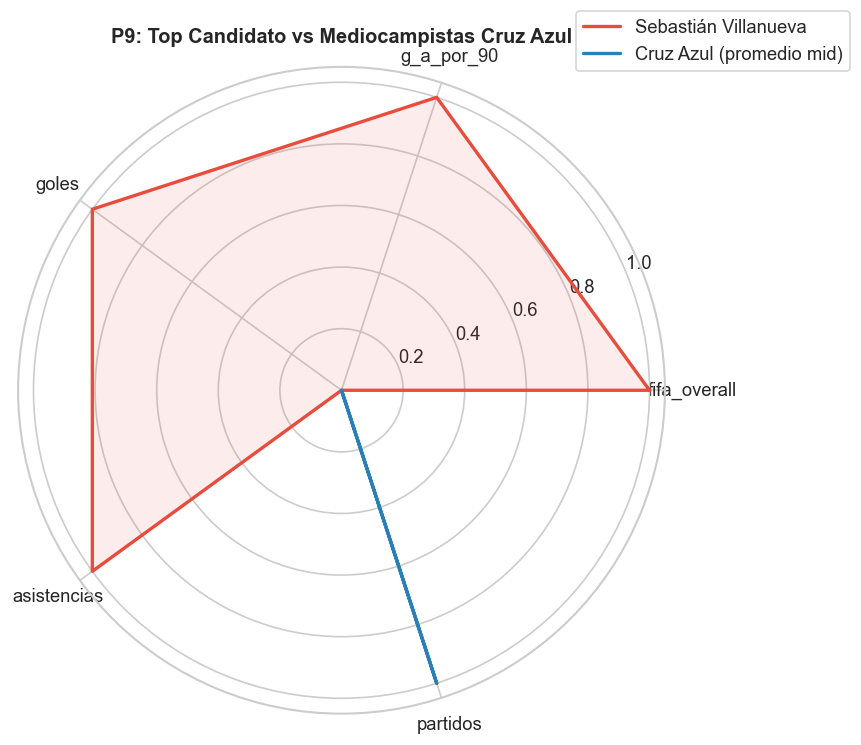

In [25]:
# P9 — Mejor mediocampista disponible para Cruz Azul (presupuesto <= 3 M USD)

BUDGET_USD = 3_000_000
EUR_USD    = 1.08
BUDGET_EUR = BUDGET_USD / EUR_USD

# ── Posiciones de mediocampo
mid_kw = ['CM', 'CDM', 'CAM', 'MC', 'MCD', 'MCC', 'MCO', 'MI', 'MD',
          'Centrocampista', 'Mediocamp', 'MF', 'DM', 'AM']
mid_pattern = '|'.join(mid_kw)

mids = df[
    df['posicion'].str.contains(mid_pattern, case=False, na=False) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] > 0) &
    (df['valor_mercado_eur'] <= BUDGET_EUR) &
    ~es_ca(df['equipo_norm'])
].copy()

print('Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD):', len(mids))

if len(mids) == 0:
    print('Sin coincidencias exactas — ampliando presupuesto x2')
    mids = df[
        df['posicion'].str.contains(mid_pattern, case=False, na=False) &
        df['valor_mercado_eur'].notna() &
        (df['valor_mercado_eur'] > 0) &
        (df['valor_mercado_eur'] <= BUDGET_EUR * 2) &
        ~es_ca(df['equipo_norm'])
    ].copy()

# ── Índice compuesto
mids_clean = mids.dropna(subset=['fifa_overall', 'g_a_por_90']).copy()
sc = MinMaxScaler()

mids_clean['ov_n']   = sc.fit_transform(mids_clean[['fifa_overall']])
mids_clean['ga_n']   = sc.fit_transform(mids_clean[['g_a_por_90']].fillna(0))
vm_n_vals = 1 - sc.fit_transform(mids_clean[['valor_mercado_eur']])
mids_clean['vm_n']   = vm_n_vals
mids_clean['edad_n'] = 1 - sc.fit_transform(mids_clean[['edad']].fillna(30))

mids_clean['indice'] = (0.40 * mids_clean['ov_n'] +
                        0.30 * mids_clean['ga_n'] +
                        0.20 * mids_clean['vm_n'] +
                        0.10 * mids_clean['edad_n'])

top5 = mids_clean.nlargest(5, 'indice')[['nombre_canonico', 'equipo_norm', 'posicion',
                                          'edad', 'fifa_overall', 'g_a_por_90',
                                          'valor_mercado_eur', 'indice']].copy()
top5['valor_mercado_eur'] = top5['valor_mercado_eur'] / 1e6

print('\n=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===')
top5_disp = top5.copy()
top5_disp.columns = ['Jugador', 'Equipo', 'Pos', 'Edad', 'Overall',
                      'G+A/90', 'Valor (M EUR)', 'Índice']
print(top5_disp.round(3).to_string(index=False))

# ── Radar chart: top candidato vs mediocampistas de Cruz Azul
radar_feats = [f for f in ['fifa_overall', 'g_a_por_90', 'goles', 'asistencias', 'partidos']
               if f in df.columns]
ca_mids = df[
    es_ca(df['equipo_norm']) &
    df['posicion'].str.contains(mid_pattern, case=False, na=False)
][radar_feats + ['nombre_canonico']].dropna()

if len(top5) > 0 and len(ca_mids) > 0:
    cand_name = top5.iloc[0]['nombre_canonico']
    cand_rows = mids_clean[mids_clean['nombre_canonico'] == cand_name][radar_feats]
    if len(cand_rows) == 0:
        cand_rows = mids_clean[radar_feats].iloc[[0]]
    cand_row = cand_rows.iloc[0]
    ca_mean  = ca_mids[radar_feats].mean()

    sc_r = MinMaxScaler()
    combined = pd.DataFrame([cand_row.values, ca_mean.values], columns=radar_feats)
    combined_n = pd.DataFrame(sc_r.fit_transform(combined), columns=radar_feats)

    angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for i, (label, color) in enumerate(zip(
            [cand_name, 'Cruz Azul (promedio mid)'], ['#E74C3C', '#2980B9'])):
        vals = combined_n.iloc[i].tolist() + [combined_n.iloc[i].tolist()[0]]
        ax_r.plot(angles, vals, color=color, lw=2, label=label)
        ax_r.fill(angles, vals, color=color, alpha=0.1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_feats)
    ax_r.set_title('P9: Top Candidato vs Mediocampistas Cruz Azul', fontweight='bold', pad=15)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

---
## P10 — ¿Qué debilidades tácticas tiene Cruz Azul y qué perfil de jugador necesita?
> **Método:** Analizar goles concedidos por jornada en partidos de Cruz Azul. Comparar atributos defensivos FIFA vs los 3 equipos más sólidos de la liga. Identificar perfil y candidatos.  
> **Visualización:** Heatmap de goles concedidos + radar defensivo comparativo.

Equipos más sólidos defensivamente: ['TOLUCA', 'CLUB LEON', 'LEON']
Goles concedidos promedio por partido:
TOLUCA       1.378
CLUB LEON    1.392
LEON         1.440
Name: gc_total, dtype: float64

Cruz Azul — goles concedidos promedio por partido: 1.603


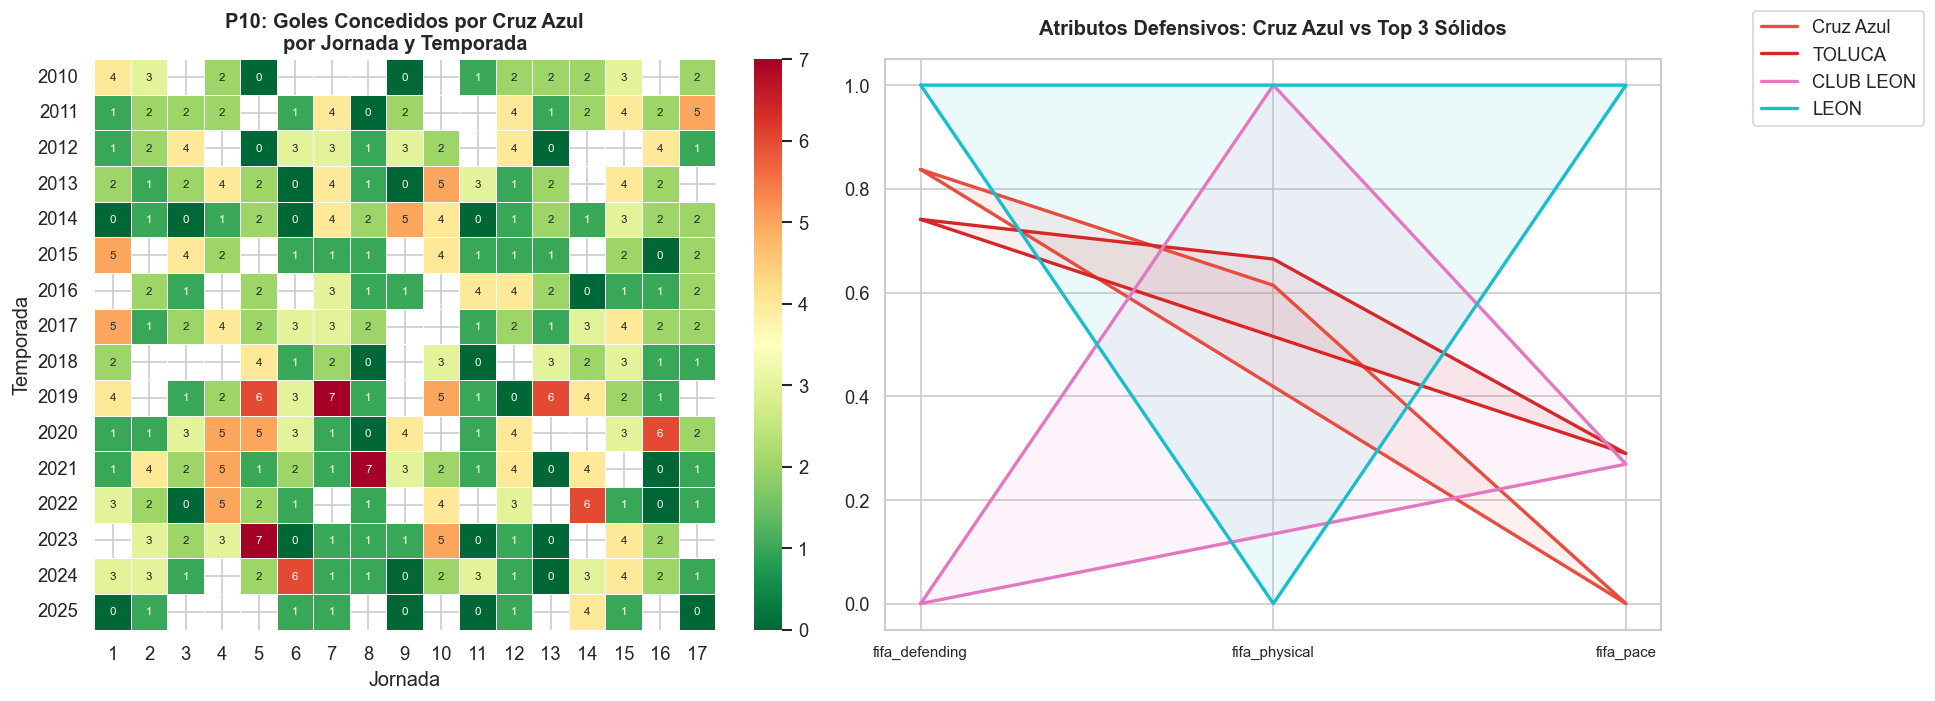


=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===
Gap atributos defensivos (Top3 - Cruz Azul):
fifa_defending   -1.1
fifa_physical    -0.2
fifa_pace         3.3

=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===
  nombre_canonico        equipo_norm posicion  edad  defending  overall  Valor M
     Lucas Suárez            TIJUANA       CB    17         85       71     0.80
 Fernando Álvarez       CLUB AMERICA      CDM    26         85       82     2.65
     Héctor Rivas        TIGRES UANL      CDM    28         85       83     4.35
    Erick Aguirre  ATLETICO SAN LUIS      CDM    18         85       69     1.25
Rodrigo Fernández CHIVAS GUADALAJARA       CB    33         85       82     1.90
 Santiago Giménez          FC JUAREZ       RB    37         85       73     0.70
     Jorge Lozano      SANTOS LAGUNA       RB    30         85       70     1.05
     Marco Moreno      BRAVOS JUAREZ      CDM    21         85       66     0.95
      Alan Macías CHIVAS GUADALAJARA      CD

In [26]:
# P10 — Debilidades tácticas Cruz Azul

# ── Goles concedidos por Cruz Azul por temporada/jornada
ca_local = partidos[es_ca(partidos['equipo_local_norm'])].copy()
ca_visit = partidos[es_ca(partidos['equipo_visitante_norm'])].copy()

ca_local['goles_concedidos'] = ca_local['goles_visitante']
ca_local['goles_favor']      = ca_local['goles_local']
ca_visit['goles_concedidos'] = ca_visit['goles_local']
ca_visit['goles_favor']      = ca_visit['goles_visitante']

ca_all = pd.concat([ca_local[['season_year', 'round', 'goles_concedidos', 'goles_favor']],
                    ca_visit[['season_year', 'round', 'goles_concedidos', 'goles_favor']]])
ca_all = ca_all.dropna(subset=['goles_concedidos', 'season_year', 'round'])
ca_all['season_year'] = ca_all['season_year'].astype(int)
ca_all['round']       = ca_all['round'].astype(int)

# ── Heatmap goles concedidos por jornada/temporada
pivot_gc = ca_all.pivot_table(index='season_year', columns='round',
                               values='goles_concedidos', aggfunc='sum')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_gc, cmap='RdYlGn_r', ax=ax1,
            linewidths=0.3, annot=True, fmt='.0f', annot_kws={'size': 7})
ax1.set_title('P10: Goles Concedidos por Cruz Azul\npor Jornada y Temporada', fontweight='bold')
ax1.set_xlabel('Jornada')
ax1.set_ylabel('Temporada')

# ── Atributos defensivos: Cruz Azul vs top 3 defensivos de la liga
def_feats = ['fifa_defending', 'fifa_physical', 'fifa_pace']
def_feats_ok = [f for f in def_feats if f in df.columns]

# Equipos que menos goles conceden (promedio por partido)
gc_eq_local = (partidos.groupby('equipo_local_norm')['goles_visitante']
               .mean().rename('gc_local'))
gc_eq_visit = (partidos.groupby('equipo_visitante_norm')['goles_local']
               .mean().rename('gc_visit'))
gc_eq = pd.concat([gc_eq_local, gc_eq_visit], axis=1)
gc_eq['gc_total'] = gc_eq.mean(axis=1)
top3_def = gc_eq.nsmallest(3, 'gc_total').index.tolist()

print('Equipos más sólidos defensivamente:', top3_def)
print('Goles concedidos promedio por partido:')
print(gc_eq.loc[top3_def, 'gc_total'].round(3))

ca_gc = ca_all['goles_concedidos'].mean()
print('\nCruz Azul — goles concedidos promedio por partido:', round(ca_gc, 3))

# ── Radar defensivo
if len(def_feats_ok) > 0:
    def_df = df[def_feats_ok + ['equipo_norm']].dropna()

    groups_names = ['Cruz Azul'] + [t for t in top3_def]
    groups_masks = [es_ca(def_df['equipo_norm'])] + [
        def_df['equipo_norm'].str.contains(t.split()[0], case=False, na=False)
        for t in top3_def]

    profiles = []
    valid_names = []
    for name, mask in zip(groups_names, groups_masks):
        sub = def_df[mask][def_feats_ok]
        if len(sub) > 0:
            profiles.append(sub.mean().values)
            valid_names.append(name)

    if len(profiles) > 1:
        sc_r2 = MinMaxScaler()
        profiles_n = sc_r2.fit_transform(np.array(profiles))

        angles2 = np.linspace(0, 2 * np.pi, len(def_feats_ok), endpoint=False).tolist()
        angles2 += angles2[:1]
        cmap = plt.cm.get_cmap('tab10', len(valid_names))

        for i, (name, pn) in enumerate(zip(valid_names, profiles_n)):
            vals2 = pn.tolist() + [pn[0]]
            color2 = '#E74C3C' if 'Cruz' in name else cmap(i)
            ax2.plot(angles2, vals2, color=color2, lw=2, label=name)
            ax2.fill(angles2, vals2, color=color2, alpha=0.08)

        ax2.set_xticks(angles2[:-1])
        ax2.set_xticklabels(def_feats_ok, fontsize=9)
        ax2.set_title('Atributos Defensivos: Cruz Azul vs Top 3 Sólidos', fontweight='bold', pad=15)
        ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    else:
        ax2.text(0.5, 0.5, 'Datos insuficientes para radar', ha='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'Columnas FIFA defensivas no disponibles', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

# ── Perfil del jugador a fichar y candidatos
print('\n=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===')
if len(def_feats_ok) > 0:
    ca_def_mean = def_df[es_ca(def_df['equipo_norm'])][def_feats_ok].mean()
    liga_top_mean = def_df[def_df['equipo_norm'].isin(top3_def)][def_feats_ok].mean()
    gap = (liga_top_mean - ca_def_mean).round(1)
    print('Gap atributos defensivos (Top3 - Cruz Azul):')
    print(gap.to_string())

# ── Candidatos: defensores/mediocampistas defensivos con alto defending
def_pos_kw = ['CB', 'RB', 'LB', 'CDM', 'SW', 'DC', 'DF', 'Defensa', 'Central']
def_pos_pat = '|'.join(def_pos_kw)

candidatos_def = df[
    df['posicion'].str.contains(def_pos_pat, case=False, na=False) &
    ~es_ca(df['equipo_norm']) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] <= 5_000_000)
].copy()

if 'fifa_defending' in df.columns:
    candidatos_def = candidatos_def.dropna(subset=['fifa_defending'])
    candidatos_def = candidatos_def.sort_values('fifa_defending', ascending=False)
    print('\n=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===')
    cols_disp = ['nombre_canonico', 'equipo_norm', 'posicion', 'edad',
                 'fifa_defending', 'fifa_overall', 'valor_mercado_eur']
    cols_ok = [c for c in cols_disp if c in candidatos_def.columns]
    disp_cand = candidatos_def[cols_ok].head(10).copy()
    disp_cand['valor_mercado_eur'] = disp_cand['valor_mercado_eur'] / 1e6
    disp_cand.columns = [c.replace('fifa_', '').replace('valor_mercado_eur', 'Valor M')
                          for c in disp_cand.columns]
    print(disp_cand.round(2).to_string(index=False))
else:
    print('Columna fifa_defending no disponible — usando fifa_overall como proxy')
    candidatos_def = candidatos_def.dropna(subset=['fifa_overall'])
    print(candidatos_def[['nombre_canonico', 'equipo_norm', 'posicion',
                           'fifa_overall', 'valor_mercado_eur']]
          .nlargest(10, 'fifa_overall').round(2).to_string(index=False))